# Volumetric Noise Analysis

In [22]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
import skimage
import scipy
import toml

from numpy.typing import NDArray
from scipy.ndimage import gaussian_filter1d, map_coordinates

import sys

sys.path.insert(0, str(Path.cwd().parent))

from metal import estimate_metal_threshold, extract_metal_mask
from noise import estimate_volume_slice_stats, fit_mixture_distribution
from utils import estimate_grayscale_range, identify_cylindrical_support
from enhance import softmax_projection

from volume import load_volume


# Configuration & Utilities

In [7]:
cfg = toml.load(Path.cwd().parent / "config.toml")
print(cfg["paths"])
data_dir = Path(cfg["paths"]["vol_data_path"])
vol = load_volume(data_dir)
z_top, z_bottom = cfg["analysis"]["vol_top"], cfg["analysis"]["vol_bottom"]
vol = vol[z_top:z_bottom]
vol_center_row = (vol.shape[1]) / 2
vol_center_col = (vol.shape[2]) / 2
pixel_size_mm = cfg["vol_info"]["voxel_size"]
print(f"Shape : {vol.shape}\nDtype : {vol.dtype}\nVoxel : {pixel_size_mm} mm")

{'vol_data_path': '/Users/jim/Documents/GitHub/particles/Data/M50L-06.raw'}
Shape : (3860, 1425, 1425)
Dtype : uint8
Voxel : 0.01640435 mm


# Estimate the Landmark Grayscale Values

In [8]:
# estimate_metal_threshold, extract_metal_mask, estimate_grayscale_range

air_val, max_val = estimate_grayscale_range(vol, slice_step=200)
metal_threshold = estimate_metal_threshold(vol, air_val, slice_step=200)
print(f"Air value: {air_val}, Max value: {max_val}, Metal threshold: {metal_threshold}")


Right Peak: 128, Other Peaks: [180], Prominences: [27873.37069309]
Air value: 93, Max value: 219, Metal threshold: 154


# Create a histogram of residual

In [ ]:
slice_step = 200
slice_steps = list(range(1, vol.shape[0] - 1, slice_step))
data = np.array([])
for st in slice_steps:
    slice1 = vol[st - 1]
    slice2 = vol[st]
    _max = np.max(vol[st - 1 : st + 2], axis=0)
    metal = extract_metal_mask(_max, metal_threshold, min_area=200)
    support = identify_cylindrical_support(_max)
    diff = slice2.astype(np.int16) - slice1.astype(np.int16)
    slice_data = diff[support]
    data = np.concatenate((data, slice_data), axis=0)


In [57]:
w, mu, std = fit_mixture_distribution(data, clip_scale=2.5)
print(f"Delta weight: {w:.3f}, Mean: {mu:.3f}, Std: {std:.3f}")

Delta weight: 0.302, Mean: 0.001, Std: 3.246


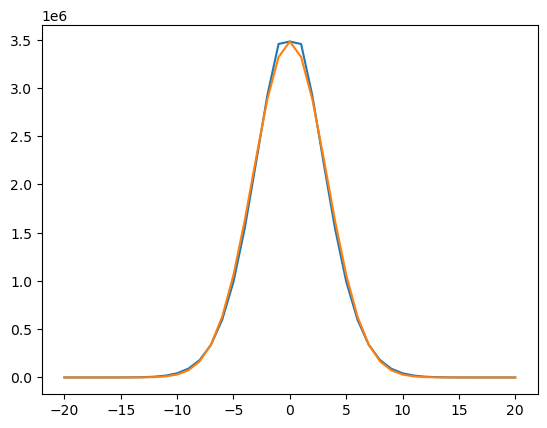

In [62]:
hist, bin_edges = np.histogram(data, bins = 511, range=(-255, 256))
bin_edges = bin_edges[:-1]


area = np.sum(hist)
h0 = hist[len(hist)//2]
hist[len(hist)//2] = round(h0 - area * (w))
gaussian = scipy.stats.norm.pdf(bin_edges, mu, std)
range = slice(235, -235)
plt.plot(bin_edges[range], hist[range])
plt.plot(bin_edges[range], gaussian[range] * hist.sum())

# Core gray value threshold

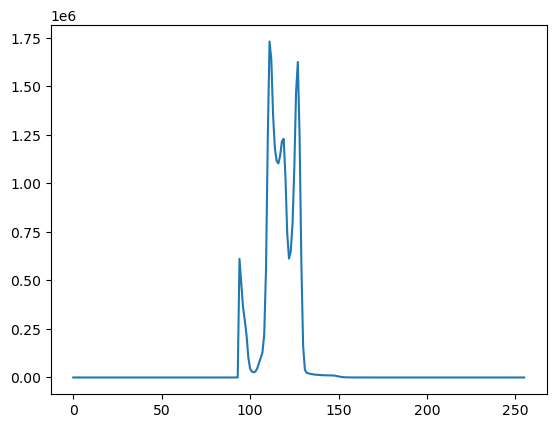

In [134]:
hist = np.zeros(256, dtype=np.float32)  # Initialize histogram for gray values
for st in slice_steps:
    slice = vol[st]
    slice = cv2.GaussianBlur(slice.astype(np.float32), (7, 7), 0)
    _max = np.max(vol[st - 1 : st + 2], axis=0)
    metal = extract_metal_mask(_max, metal_threshold, min_area=200)
    support = identify_cylindrical_support(_max)
    support &= ~metal
    #support &= slice > air_val
    slice_data = slice[support]
    _hist = cv2.calcHist([slice_data.astype(np.uint8)], [0], None, [256], [0, 256]).squeeze()
    hist += _hist

hist[:air_val+1] = 0  # Ignore air gray values for max gray value estimation
plt.plot(hist)



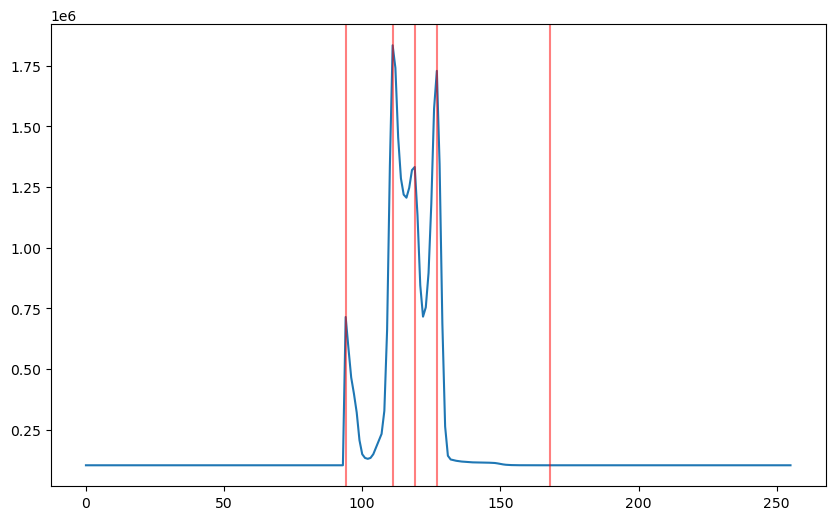

In [135]:
plt.figure(figsize=(10, 6))
plt.plot(hist + hist.mean(), label="Inverted Histogram")
pks, pk_info = scipy.signal.find_peaks(hist + hist.mean(), prominence=0.5)
for pk in pks:
    plt.axvline(x=pk, color="red", alpha=0.5)

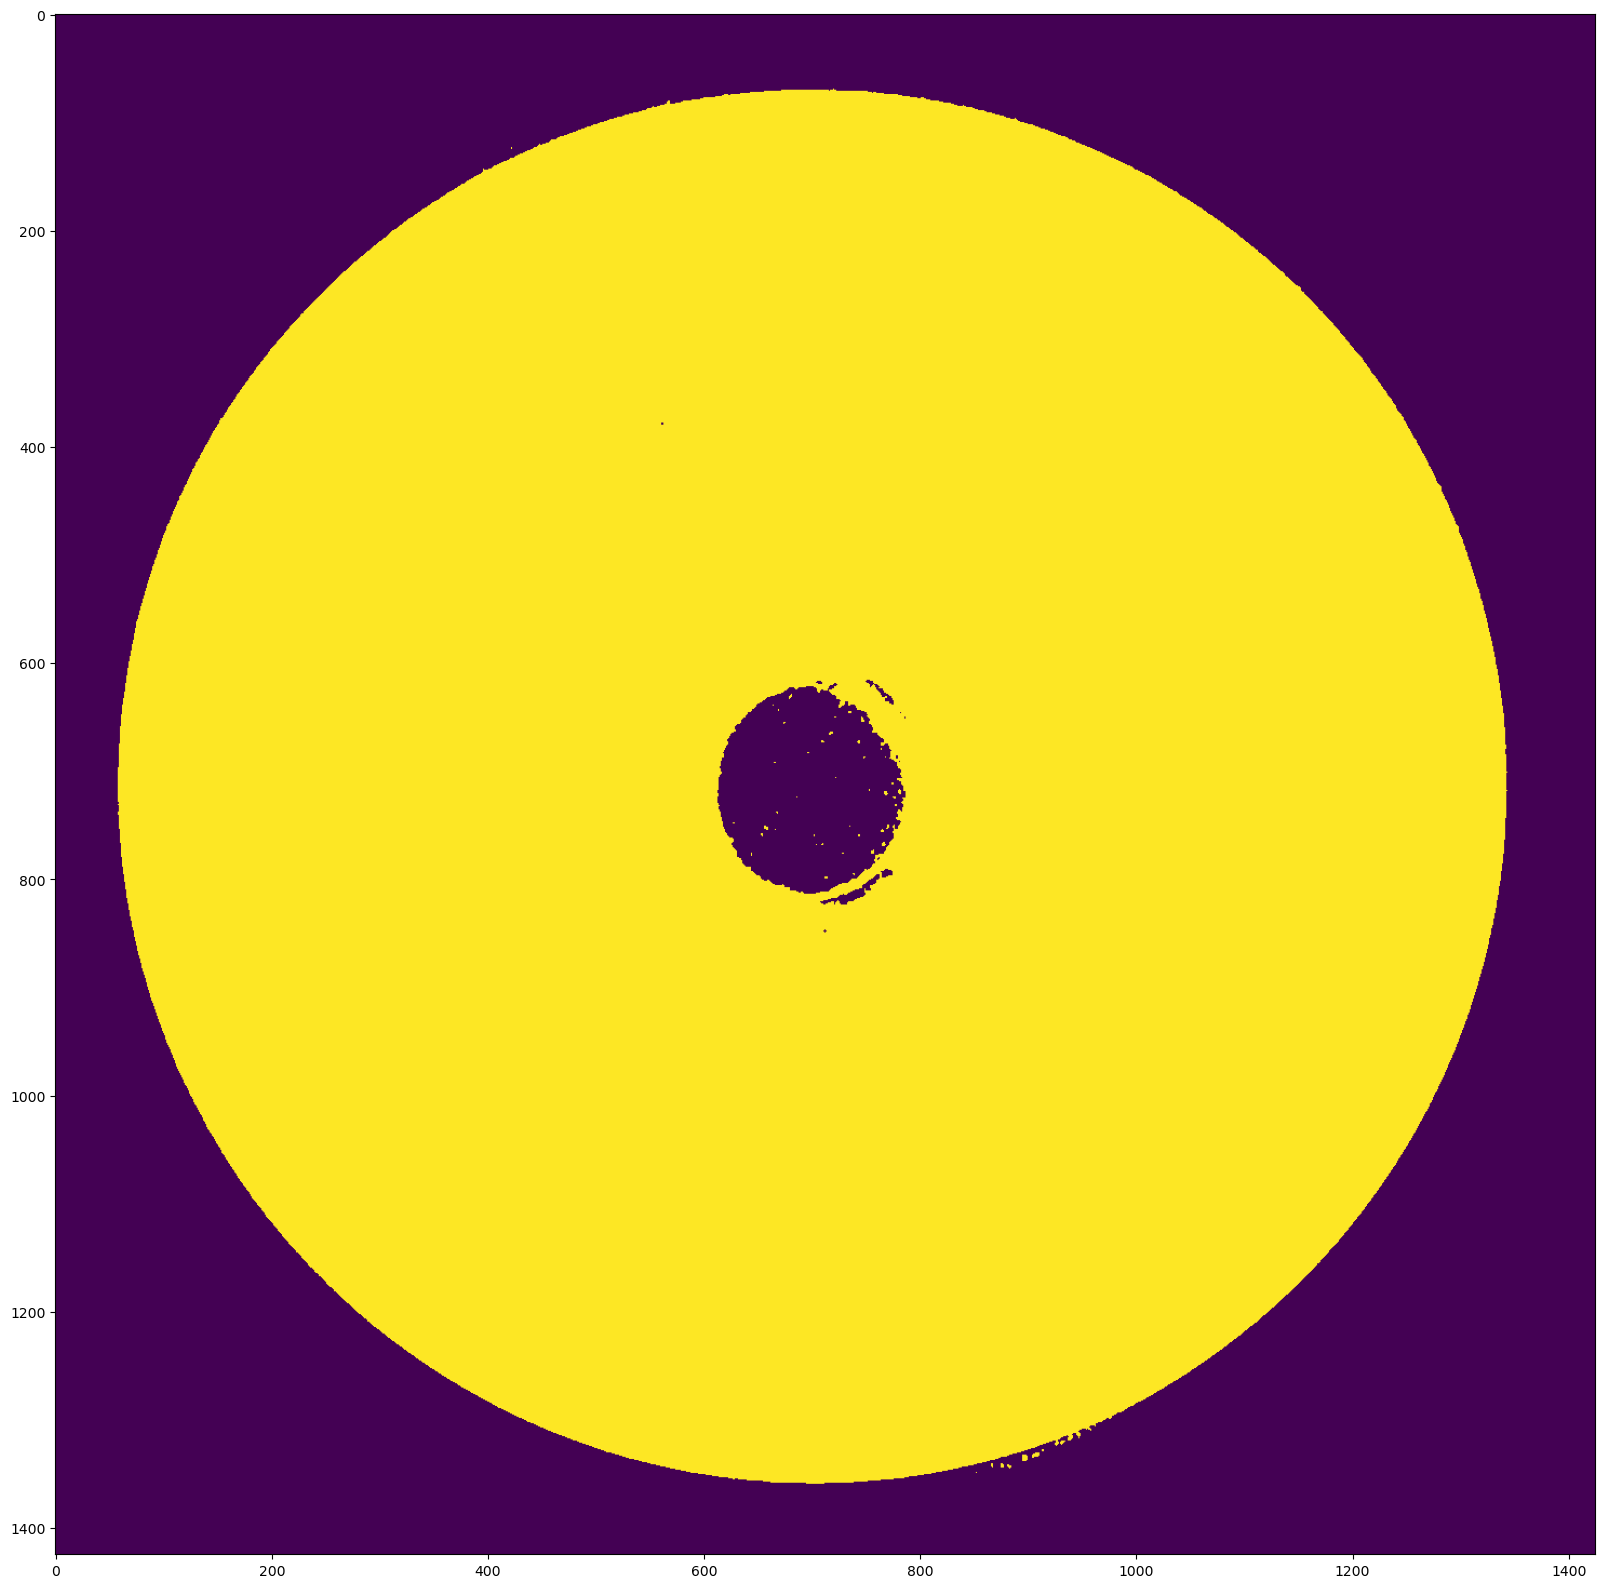

In [137]:
plt.figure(figsize=(20, 20))
slice = vol[1200]
slice = cv2.GaussianBlur(slice.astype(np.float32), (7, 7), 0)
plt.imshow(slice>100)

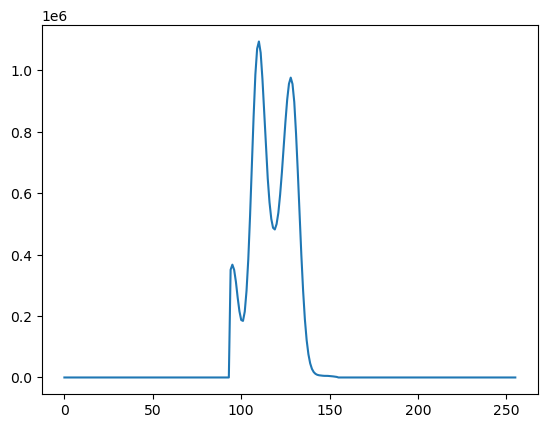

In [107]:
import scipy
plt.plot(hist)
#pks = scipy.signal.find_peaks(-hist)
#print(pk_info)
##plt.plot(hist)
for pk in pks[0]:
    pass#plt.axvline(x=bins[pk], color="red", alpha=0.5)

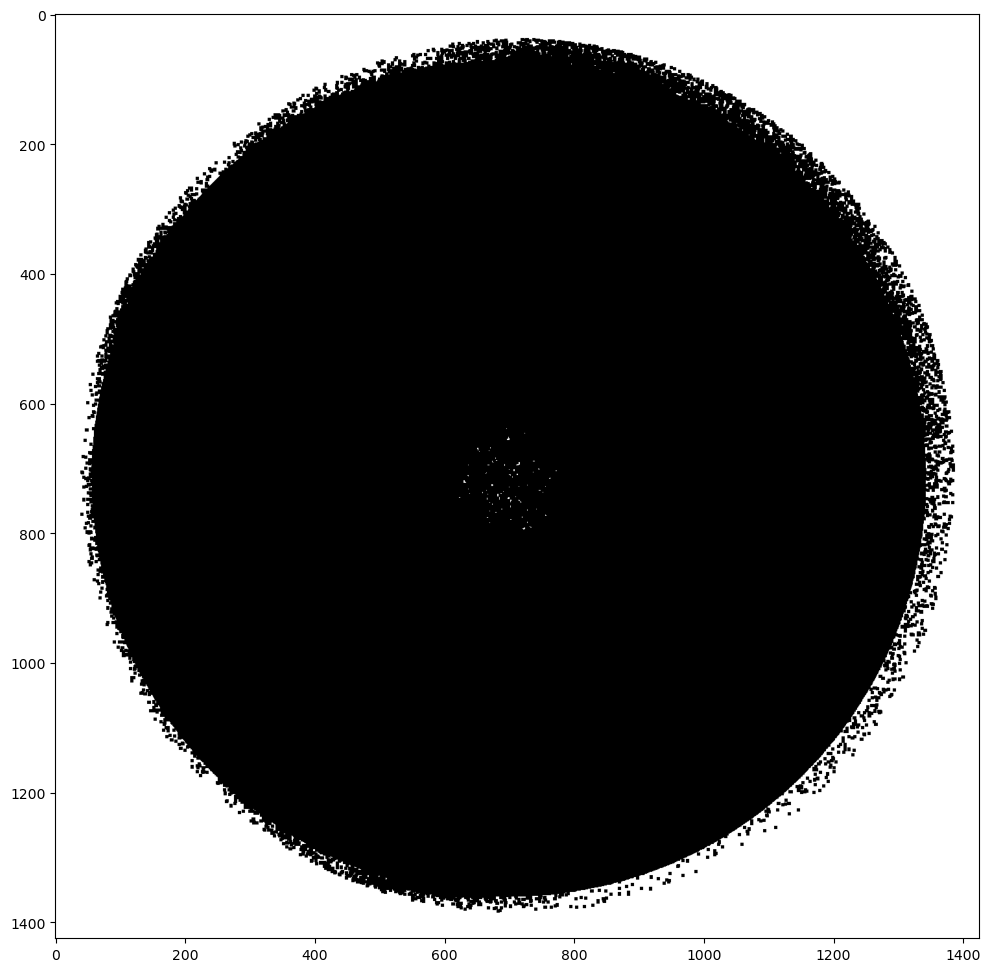

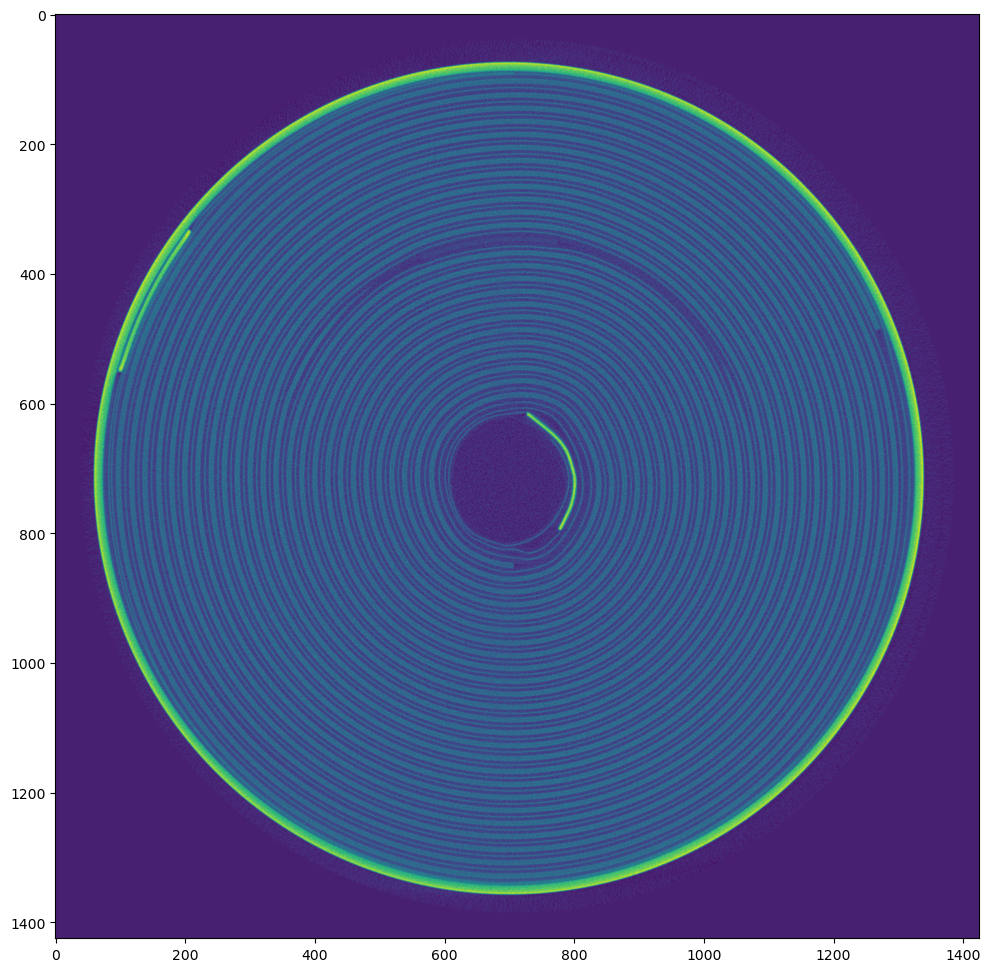

In [93]:
plt.figure(figsize=(12, 12))
slice = vol[1000]
T = air_val + 1 + pks[0][0]
mask = slice < T
mask = skimage.morphology.erosion(mask, np.ones((5, 5), dtype=bool))
#mask = skimage.morphology.dilation(mask, np.ones((11, 11), dtype=bool))
plt.imshow(mask, cmap="gray")
plt.show()
plt.figure(figsize=(12, 12))
plt.imshow(slice)

# Inspect the influence of regions outside the can

In [56]:
slice_idx = 1000
slice1 = vol[slice_idx, :, :]
slice2 = vol[slice_idx + 1, :, :]
stack = np.concatenate([slice1, slice2], axis=0)
metal_mask = extract_metal_mask(
    np.max(vol[slice_idx : slice_idx + 2, :, :], axis=0), metal_threshold, min_area=200
)

Fitted parameters: w=0.3090, mu=0.0002, sigma=3.3481


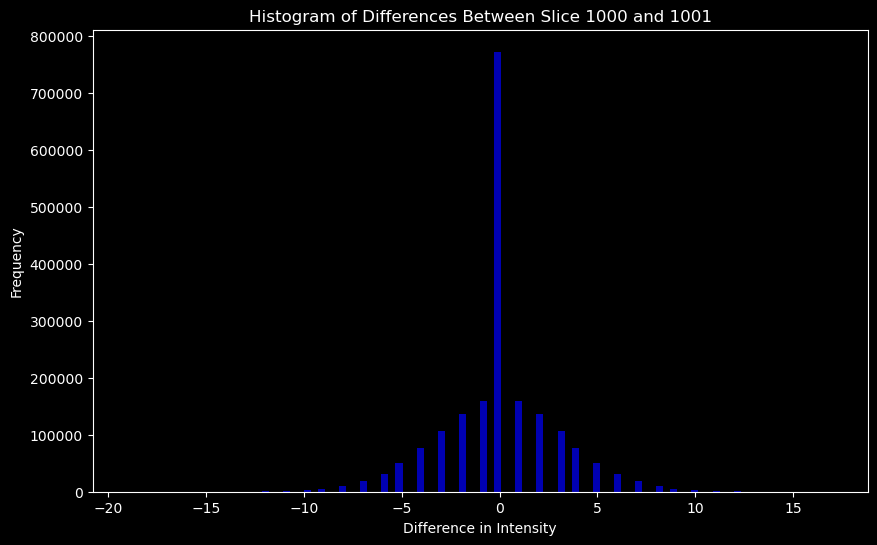

In [ ]:
from noise import fit_mixture_distribution

diff_all = slice2.astype(np.int16) - slice1.astype(np.int16)
w_all, mu_all, sigma_all = fit_mixture_distribution(
    diff_all[~metal_mask], clip_scale=2.5
)
print(f"Fitted parameters: w={w_all:.4f}, mu={mu_all:.4f}, sigma={sigma_all:.4f}")

# plot the histogram of the differences
plt.figure(figsize=(10, 6))
plt.hist(diff_all[~metal_mask].flatten(), bins=100, color="blue", alpha=0.7)
plt.title(f"Histogram of Differences Between Slice {slice_idx} and {slice_idx + 1}")
plt.xlabel("Difference in Intensity")
plt.ylabel("Frequency")
plt.show()

# Now strip the data outside of the outer can wall

np.float64(3.424749337975153)

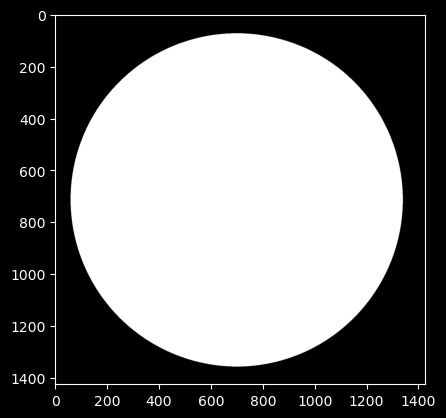

In [ ]:
smask = identify_cylindrical_support(metal_mask)
plt.imshow(smask, cmap="gray")

diff_all[~metal_mask & smask].std()

In [ ]:
w_in, mu_in, sigma_in = fit_mixture_distribution(
    diff_all[inside.astype(bool) & ~metal_mask.astype(bool)], clip_scale=2.5
)

print(
    f"Fitted parameters for inside region: w={w_in:.4f}, mu={mu_in:.4f}, sigma={sigma_in:.4f}"
)


Fitted parameters for inside region: w=0.0029, mu=-0.0007, sigma=3.3807


# Quick and dirty Global Noise Estimation

## Gather data

In [6]:
slice_step = 10
data: list[np.uint8] = []
slice_levels = list(range(1, vol.shape[0] - 1, slice_step))
if vol.shape[0] - 2 not in slice_levels:
    slice_levels.append(vol.shape[0] - 2)

for sl in slice_levels:
    diff = vol[sl].astype(np.int16) - vol[sl - 1].astype(np.int16)
    data.append(diff)

data = np.array(data)
var_data = data[data < metal_threshold].ravel().var()
print(f"Variance of the data: {var_data:.2f}, std: {var_data**0.5:.2f}")

var_nonzero_data = data[(data != 0) & (data < metal_threshold)].ravel().var()
print(
    f"Variance of the non-zero data: {var_nonzero_data:.2f}, std: {var_nonzero_data**0.5:.2f}"
)


Variance of the data: 7.50, std: 2.74
Variance of the non-zero data: 12.25, std: 3.50


## Review histogram

58 bins, 59, range: [-31, 27], total count: 785851875
Mean (mu): 0.00, Standard Deviation (std): 2.74


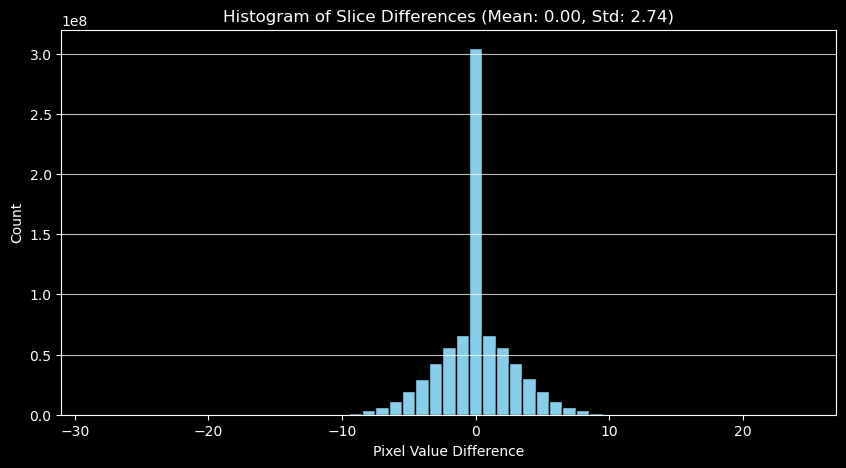

In [7]:
bins = np.arange(data.min(), data.max() + 1, 1)
hist = np.histogram(data, bins=bins)[0]
bin_edges = bins

print(
    f"{len(hist)} bins, {len(bins)}, range: [{bins[0]}, {bins[-1]}], total count: {hist.sum()}"
)

mu = np.sum(hist * bin_edges[:-1]) / hist.sum()
std = np.sqrt(np.sum(hist * (bin_edges[:-1] - mu) ** 2) / hist.sum())
print(f"Mean (mu): {mu:.2f}, Standard Deviation (std): {std:.2f}")

plt.figure(figsize=(10, 5))
plt.bar(bin_edges[:-1], hist, width=1, color="skyblue", edgecolor="black")
plt.title(f"Histogram of Slice Differences (Mean: {mu:.2f}, Std: {std:.2f})")
plt.xlabel("Pixel Value Difference")
plt.ylabel("Count")
plt.xlim(bin_edges[0], bin_edges[-1])
plt.grid(axis="y", alpha=0.75)
plt.show()

## We'll now move to a more sophisticated means for global noise estimation that accounts for correlations in the residual

# Global Noise Estimation

In [8]:
noise_results = estimate_global_noise(
    vol, slice_levels=slice_levels, metal_threshold=None, clip_scale=2.5
)  # metal_threshold)

In [9]:
print(f"Estimated Noise Parameters:")
print(f"    global noise: {noise_results['sigma_noise_global']:.2f}")
print(f"    median noise: {noise_results['sigma_noise_median']:.2f}")
print(f"    median rho: {noise_results['rho_median']:.2f}")
print(f"    number of triplets: {noise_results['n_triplets']}")
print(f"    levels skipped: {noise_results['levels_skipped']}")

Estimated Noise Parameters:
    global noise: 3.12
    median noise: 3.11
    median rho: 0.46
    number of triplets: 387
    levels skipped: []


## Let's inspect results from the various slice_levels

In [10]:
slice_noise_results = noise_results["per_triplet"]
print(type(slice_noise_results), len(slice_noise_results))
nres = slice_noise_results[0]
nres

<class 'list'> 387


{'w': (0.30306884846370513, 0.30346163266117226),
 'mu': (0.002207777353019526, 0.0024117851608316193),
 'sigma_diff': (2.8552887558685867, 2.8650334595839038),
 'var_survivor': (9.691644916462337, 9.75875509480588),
 'sigma_diff_pooled': 2.860165257806347,
 'r': -0.0788643604610644,
 'rho': 0.4571917766092847,
 'sigma_noise': 2.745066816764287,
 'n_valid': 2030625,
 'n_survivor': 1040854,
 'level': 1}

## The means

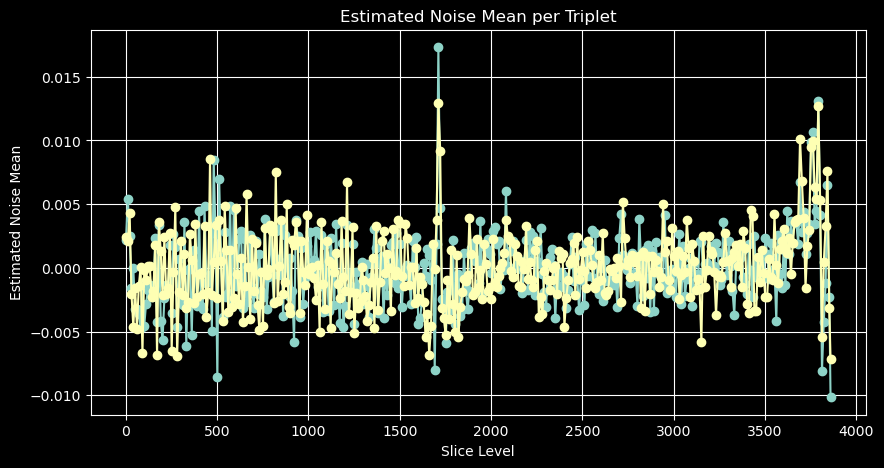

In [11]:
means = [nres["mu"] for nres in slice_noise_results]
plt.figure(figsize=(10, 5))
plt.plot(slice_levels[: len(means)], means, marker="o")
plt.title("Estimated Noise Mean per Triplet")
plt.xlabel("Slice Level")
plt.ylabel("Estimated Noise Mean")
plt.grid()
plt.show()

## The number of survivors

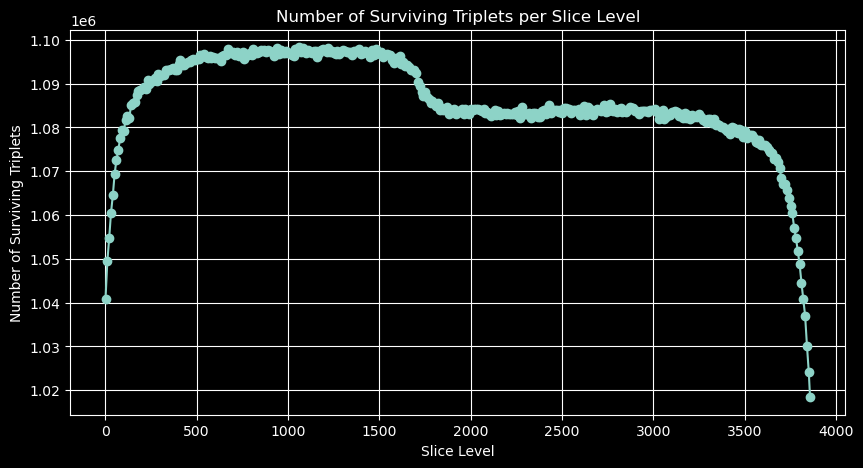

In [12]:
n_surv = [res["n_survivor"] for res in slice_noise_results]
plt.figure(figsize=(10, 5))
plt.plot(slice_levels[: len(n_surv)], n_surv, marker="o")
plt.title("Number of Surviving Triplets per Slice Level")
plt.xlabel("Slice Level")
plt.ylabel("Number of Surviving Triplets")
plt.grid()
plt.show()

## Estimated corrected noise across the slice levels

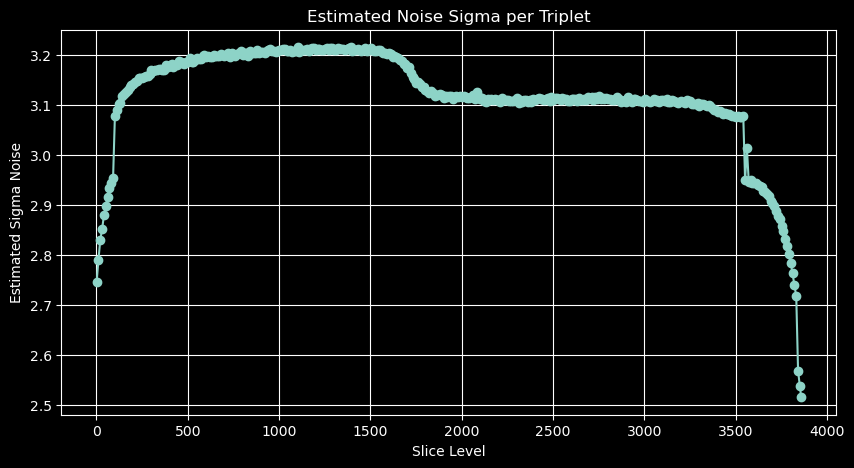

In [13]:
sn = [res["sigma_noise"] for res in slice_noise_results]
plt.figure(figsize=(10, 5))
plt.plot(slice_levels[: len(sn)], sn, marker="o")
plt.title("Estimated Noise Sigma per Triplet")
plt.xlabel("Slice Level")
plt.ylabel("Estimated Sigma Noise")
plt.grid()
plt.show()

## The correlations across the slices

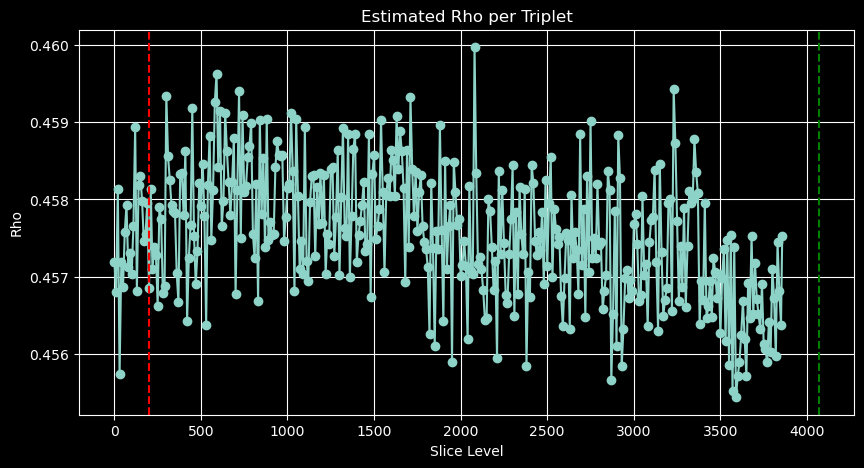

In [14]:
rho = [res["rho"] for res in slice_noise_results]
plt.figure(figsize=(10, 5))
plt.plot(slice_levels[: len(rho)], rho, marker="o")
plt.axvline(200, color="red", linestyle="--", label="Slice Level 200")
plt.axvline(4070, color="green", linestyle="--", label="Slice Level 4070")

plt.title("Estimated Rho per Triplet")
plt.xlabel("Slice Level")
plt.ylabel("Rho")
plt.grid()
plt.show()

## The raw sigma values across the slices
- There is an elevation in the noise estimate from the interior relative to the ends.
- There is also a downward trend in the middle, starting near slice 1300

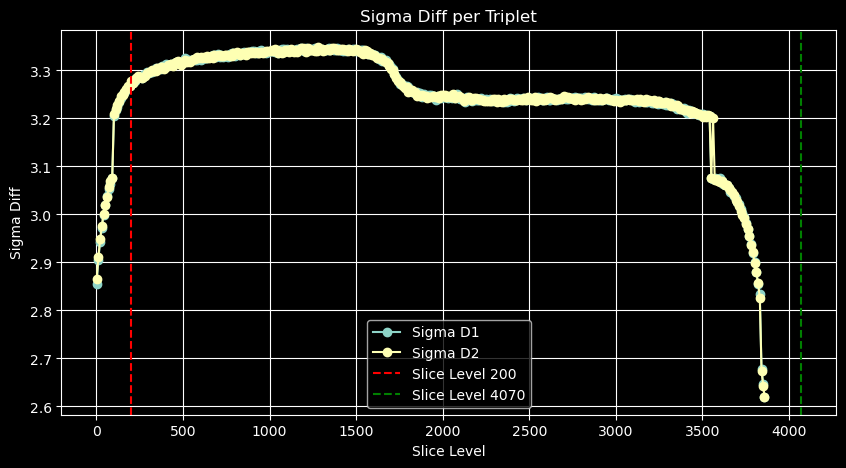

In [15]:
s1 = [res["sigma_diff"][0] for res in slice_noise_results]
s2 = [res["sigma_diff"][1] for res in slice_noise_results]
plt.figure(figsize=(10, 5))
plt.plot(slice_levels, s1, label="Sigma D1", marker="o")
plt.plot(slice_levels, s2, label="Sigma D2", marker="o")
plt.axvline(200, color="red", linestyle="--", label="Slice Level 200")
plt.axvline(4070, color="green", linestyle="--", label="Slice Level 4070")
plt.title("Sigma Diff per Triplet")
plt.xlabel("Slice Level")
plt.ylabel("Sigma Diff")
plt.legend()
plt.grid()
plt.show()

## The delta weights across the slice levels
- These look nicely matched and uniform

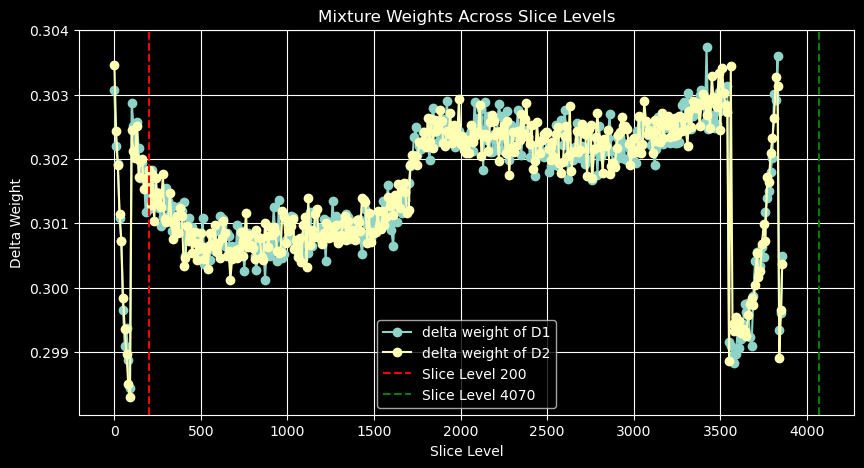

In [16]:
 w1 = [res['w'][0] for res in slice_noise_results]
 w2 = [res['w'][1] for res in slice_noise_results]

 plt.figure(figsize=(10, 5))
 plt.plot(slice_levels, w1, label='delta weight of D1', marker='o')
 plt.plot(slice_levels, w2, label='delta weight of D2', marker='o')
 plt.axvline(200, color='red', linestyle='--', label='Slice Level 200')
 plt.axvline(4070, color='green', linestyle='--', label='Slice Level 4070')

 plt.title("Mixture Weights Across Slice Levels")
 plt.xlabel("Slice Level")
 plt.ylabel("Delta Weight")
 plt.legend()
 plt.grid()

# Lag-2 estimation and inspection

In [ ]:
z0 = [500, 1000, 1500, 2000, 2500]
k = 2.0
results: dict[float, dict[str, object]] = {}
for z_ in z0:
    results[z_] = estimate_lag2_second_difference(
        vol[z_ - 2 : z_ + 3], mask=None, trunc_k=k
    )


In [46]:
for k, v in results.items():
    print(f"slice {k}: {v}")


slice 500: {'rho1': 0.5184072952562819, 'rho2': 0.09351302043450774, 'sigma_solve': 3.7555433442232347, 'sigma_core': 3.3049411221643097, 'var_d1': 13.584868930385914, 'var_d2sq': 28.769099170570254, 'cov_dd': -7.229074361130092, 'cov_dd_null': -15.142579570246477, 'n_survivor': 911818, 'valid': True}
slice 1000: {'rho1': 0.5172802886227789, 'rho2': 0.09244568484688938, 'sigma_solve': 3.7943561261706917, 'sigma_core': 3.311805628851203, 'var_d1': 13.899564997998917, 'var_d2sq': 29.46588980828181, 'cov_dd': -7.4065653185165905, 'cov_dd_null': -15.392285240629333, 'n_survivor': 915773, 'valid': True}
slice 1500: {'rho1': 0.5170657055836624, 'rho2': 0.09258319985898317, 'sigma_solve': 3.8077574206134943, 'sigma_core': 3.3055725407445467, 'var_d1': 14.004144678019987, 'var_d2sq': 29.703276262108304, 'cov_dd': -7.434568271163585, 'cov_dd_null': -15.48876036667142, 'n_survivor': 914215, 'valid': True}
slice 2000: {'rho1': 0.5146877578623408, 'rho2': 0.08940701420309831, 'sigma_solve': 3.6588